# Estadística básica: ejemplos resueltos

**Curso:** Fundamentos para Inteligencia Artificial — NRC 94103
**Semana 5:** Estadística básica y visualización de datos
**Fuente de datos:** mismos datasets usados en los casos de estudio de Matplotlib de esta semana (salario por edad, `Semana_5/Matplotlib_Parte_2`) y la *Stack Overflow Developer Survey 2019* (`Semana_5/data.csv`)

Este notebook complementa los casos de estudio de gráficos de la Semana 5 con tres bloques de estadística descriptiva aplicados a los mismos datos:

1. **Tendencia central y dispersión** (media, mediana, desviación estándar, cuartiles) sobre el salario por edad.
2. **Frecuencias y moda** sobre datos categóricos reales (lenguajes de programación declarados en la encuesta).
3. **Correlación y regresión lineal simple** entre edad y salario.

Cada bloque incluye el cálculo, una visualización con `matplotlib` y una breve lectura de los resultados.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 1. Tendencia central y dispersión — salario por edad

Reutilizamos `ages_x` y `dev_y` (salario mediano de "todos los desarrolladores") del caso de estudio de la Parte 2. Calculamos media, mediana, desviación estándar, rango y cuartiles con `pandas`.

In [2]:
ages_x = [25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]

dev_y = [38496, 42000, 46752, 49320, 53200,
         56000, 62316, 64928, 67317, 68748, 73752]

salario = pd.Series(dev_y, index=ages_x, name="salario_mediano")

print("Media:            ", round(salario.mean(), 1))
print("Mediana:          ", salario.median())
print("Desv. estándar:   ", round(salario.std(ddof=0), 1))
print("Rango:            ", salario.max() - salario.min())
print("\nCuartiles:")
print(salario.quantile([0.25, 0.5, 0.75]))

Media:             56620.8
Mediana:           56000.0
Desv. estándar:    11125.2
Rango:             35256

Cuartiles:
0.25    48036.0
0.50    56000.0
0.75    66122.5
Name: salario_mediano, dtype: float64


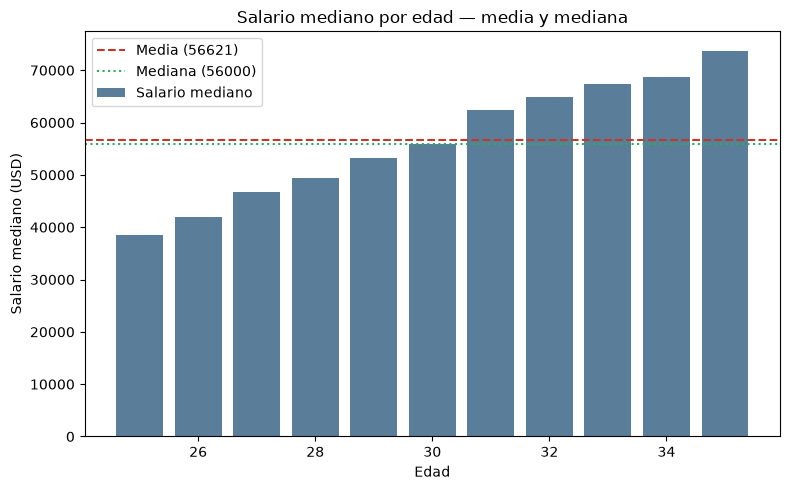

In [3]:
# Visualización: barras de salario por edad + línea de la media
plt.figure(figsize=(8, 5))
plt.bar(ages_x, dev_y, color='#5a7d9a', label='Salario mediano')
plt.axhline(salario.mean(), color='#c0392b', linestyle='--',
            label=f'Media ({salario.mean():.0f})')
plt.axhline(salario.median(), color='#27ae60', linestyle=':',
            label=f'Mediana ({salario.median():.0f})')

plt.title('Salario mediano por edad — media y mediana')
plt.xlabel('Edad')
plt.ylabel('Salario mediano (USD)')
plt.legend()
plt.tight_layout()
plt.show()

**Lectura:** la media (≈56 621 USD) es ligeramente mayor que la mediana (56 000 USD), lo que sugiere una leve cola hacia salarios más altos en las edades mayores — coherente con la tendencia creciente que ya se observó en los gráficos de líneas/barras del caso de estudio.

---

## 2. Frecuencias y moda — datos categóricos reales

Cargamos `data.csv` (87 569 encuestados, columna `LanguagesWorkedWith`) de la *Stack Overflow Developer Survey 2019*, la misma fuente usada en el caso de estudio de barras de la Parte 2. Cada respuesta es una cadena con varios lenguajes separados por `;`, así que se separa con `.split(';')` y se cuenta con `Counter`.

Como se señaló en el caso original, la categoría `Other(s):` no es un lenguaje de programación real, así que la excluimos antes de reportar la moda.

In [4]:
data = pd.read_csv('../data.csv')

language_counter = Counter()
for response in data['LanguagesWorkedWith']:
    language_counter.update(response.split(';'))

# Excluimos la categoría "Other(s):" (no es un lenguaje real)
del language_counter['Other(s):']

top_10 = language_counter.most_common(10)
languages = [item[0] for item in top_10]
popularity = [item[1] for item in top_10]

total = len(data)
print(f"Total de encuestados: {total}")
print(f"Moda (lenguaje más declarado): {top_10[0][0]} ({top_10[0][1]} encuestados, {top_10[0][1]/total:.1%})\n")
print("Top 10 — frecuencia absoluta y relativa:")
for lang, freq in top_10:
    print(f"  {lang:25s} {freq:6d}  ({freq/total:.1%})")

Total de encuestados: 87569
Moda (lenguaje más declarado): JavaScript (59219 encuestados, 67.6%)

Top 10 — frecuencia absoluta y relativa:
  JavaScript                 59219  (67.6%)
  HTML/CSS                   55466  (63.3%)
  SQL                        47544  (54.3%)
  Python                     36443  (41.6%)
  Java                       35917  (41.0%)
  Bash/Shell/PowerShell      31991  (36.5%)
  C#                         27097  (30.9%)
  PHP                        23030  (26.3%)
  C++                        20524  (23.4%)
  TypeScript                 18523  (21.2%)


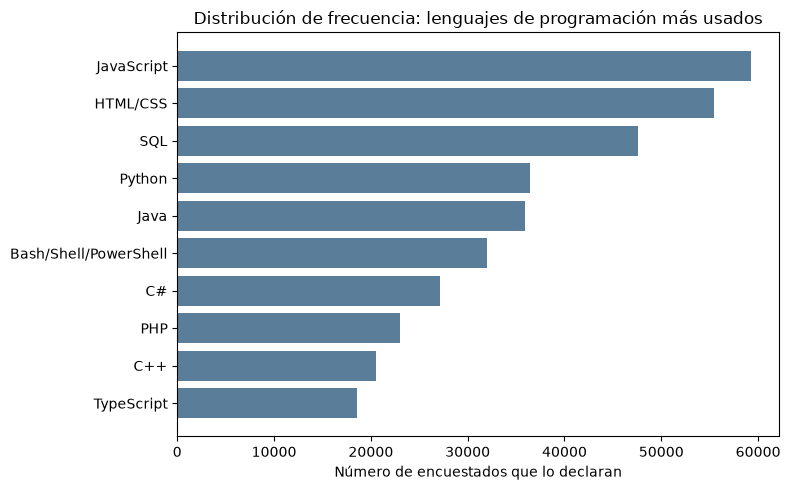

In [5]:
# Visualización: tabla de frecuencias como barras horizontales
languages_plot = languages.copy()
popularity_plot = popularity.copy()
languages_plot.reverse()
popularity_plot.reverse()

plt.figure(figsize=(8, 5))
plt.barh(languages_plot, popularity_plot, color='#5a7d9a')
plt.title('Distribución de frecuencia: lenguajes de programación más usados')
plt.xlabel('Número de encuestados que lo declaran')
plt.tight_layout()
plt.show()

**Lectura:** la moda de la variable categórica "lenguaje declarado" es JavaScript, seguido de cerca por HTML/CSS y SQL. Nótese que, al ser una variable nominal, no tiene sentido calcular media ni mediana sobre los lenguajes mismos — solo sobre sus frecuencias.

---

## 3. Correlación y regresión lineal simple — edad vs. salario

Volvemos a `ages_x` y `dev_y` para medir qué tan fuerte es la relación lineal entre edad y salario, y para ajustar una recta de regresión con `numpy.polyfit`.

In [6]:
# Correlación de Pearson
correlacion = np.corrcoef(ages_x, dev_y)[0, 1]
print("Correlación (Pearson):", round(correlacion, 3))

# Regresión lineal simple: salario = m * edad + b
m, b = np.polyfit(ages_x, dev_y, 1)
print(f"Recta ajustada: salario = {m:.1f} * edad + {b:.1f}")

# Predicción para una edad no observada en los datos (40 años)
pred_40 = m * 40 + b
print(f"Salario estimado a los 40 años: {pred_40:.0f} USD")

Correlación (Pearson): 0.996
Recta ajustada: salario = 3502.7 * edad + -48460.7
Salario estimado a los 40 años: 91648 USD


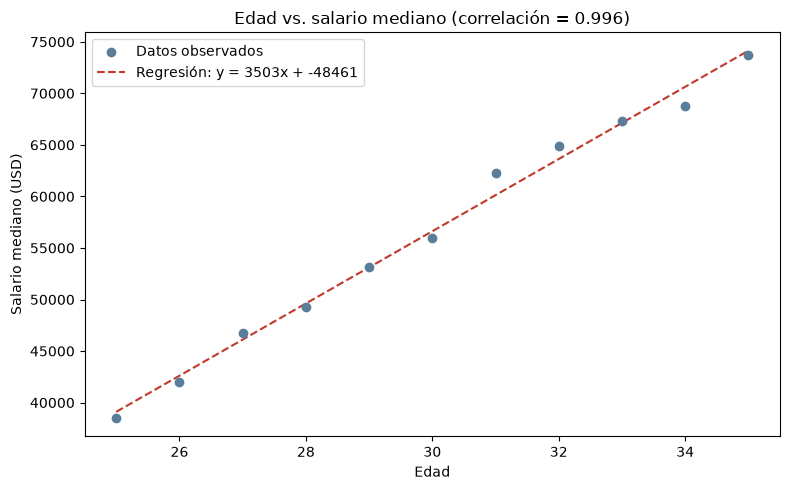

In [7]:
# Visualización: dispersión + recta de regresión
x_linea = np.array([min(ages_x), max(ages_x)])
y_linea = m * x_linea + b

plt.figure(figsize=(8, 5))
plt.scatter(ages_x, dev_y, color='#5a7d9a', label='Datos observados', zorder=3)
plt.plot(x_linea, y_linea, color='#c0392b', linestyle='--',
         label=f'Regresión: y = {m:.0f}x + {b:.0f}')

plt.title(f'Edad vs. salario mediano (correlación = {correlacion:.3f})')
plt.xlabel('Edad')
plt.ylabel('Salario mediano (USD)')
plt.legend()
plt.tight_layout()
plt.show()

**Lectura:** una correlación cercana a 1 (≈0.99) indica una relación lineal fuerte y positiva entre edad y salario dentro de este rango de edades (25-35 años). Es importante recordar que esto es correlación observada en la muestra, no causalidad, y que la recta no debe extrapolarse con confianza fuera del rango de datos observado.

---

### Síntesis

Con los tres bloques anteriores se cubrieron los tres pilares de la estadística descriptiva básica aplicada a datos reales:

- **Tendencia central y dispersión**, para resumir una variable numérica con pocos números (media, mediana, desviación estándar, cuartiles).
- **Frecuencias y moda**, para resumir una variable categórica (conteos, proporciones, categoría más común), incluyendo un paso de limpieza de datos (excluir `Other(s):`).
- **Correlación y regresión**, para cuantificar y modelar la relación lineal entre dos variables numéricas.

**Ejercicio propuesto:** repite el bloque 3 pero comparando `py_dev_y` (salario de desarrolladores Python) contra `ages_x`. ¿La correlación es más fuerte o más débil que la de `dev_y`? ¿Qué pendiente (`m`) tiene la recta ajustada en comparación con la de este notebook?